# Insect Trajectory Prediction

**TP3 — Unified Notebook (PyTorch)**

- Binôme 1:
- Binôme 2:

`Objectives`: Build neural networks to forecast the 2-D trajectory of a simulated insect.

1. Build several models: `MLP` / `RNN` / `LSTM` / `GRU` / `Transformer`.
2. Train them as **single-step** predictors (memory order `L=32`), then roll them out **autoregressively** to forecast a horizon of `T=32` steps.
3. Split the insect dataset into train / test sets.
4. Build a reusable `Experiment` (train + evaluate) routine.
5. Compare the performance of the different models.
6. Conclude from the experimental results.

**Remark**: the notebook is kept clean and readable — only the essential plots are produced.

## Notebook structure

This template walks through a full trajectory-forecasting pipeline, from raw
simulation to a multi-step forecast. It is meant to be run **top to bottom**.

The pipeline is organised into nine sections. **Section 1** collects all the
hyper-parameters. **Section 2** simulates the insect motion, and **Section 3**
turns that motion into standardised train / test sets — here you must complete
the **standardisation** code. **Section 4** slices the series into
`(window → next point)` samples. **Section 5** defines the models: `Linear` is
given as a worked example, while `MLP`, `RNN`, `LSTM`, `GRU` and `Transformer`
are left for you to implement. **Section 6** provides the training and
evaluation utilities, **Section 7** trains every enabled model and reports a
benchmark table, and **Section 8** rolls the models out autoregressively to
forecast a full horizon and plots the predictions. Finally, **Section 9** is the
conclusion, which you fill in from your results.

In short, everything except three parts is provided for you: the
**standardisation** (Section 3), the **five models** (Section 5), and the
**conclusion** (Section 9) — each marked with a `TODO`. `Linear` runs out of the
box, so the whole notebook executes end-to-end from the start; as you implement
and enable more models in the `MODELS` factory, the benchmark table and plots
update automatically.

In [1]:
import random
from math import sin, cos

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(0)
np.random.seed(0)
print('Using device:', device)

Using device: cpu


## 1. Parameters

gather every hyper-parameter in one place so the whole pipeline is easy
to reconfigure. The cell below sets the **dataset** options (simulation length,
time step, channels `C=2`, window length `L=sequence_len`, forecast horizon
`T=predict_len`, train/test split) and the **training** options (batch size,
epochs, learning rate). Run it once; later sections read these variables.

In [2]:
# ---- Dataset ---------------------------------------------------
max_t        = 100      # simulation horizon (time units)
delta_t      = 0.01     # time step
features_len = 2        # (x, y)

sequence_len = 32       # memory order L : length of the input window
predict_len  = 32       # horizon T : number of autoregressive steps to forecast

# ---- Training --------------------------------------------------
scale        = 0.2      # fraction of the simulated trajectory to use (1 = all)
train_prop   = 0.8      # train / test split ratio
batch_size   = 32
epochs       = 20
lr           = 1e-3

## 2. Insect simulation

generate a synthetic but realistic 2-D insect trajectory to forecast.

The next cell defines two functions:
- `insect_init(s)` — draws 8 Gaussian parameters per axis, seeded for reproducibility.
- `insect_move(t)` — returns the position `(x, y)` at time `t` as a sum of
  sine / cosine terms, giving a smooth, quasi-periodic motion.

In [3]:
def insect_init(s=122):
    if s > 0:
        random.seed(s)
    insect_init.params_x = [random.gauss(0., 1.) for _ in range(8)]
    insect_init.params_y = [random.gauss(0., 1.) for _ in range(8)]


def insect_move(t):
    [ax1, ax2, ax3, ax4, kx1, kx2, kx3, kx4] = insect_init.params_x
    [ay1, ay2, ay3, ay4, ky1, ky2, ky3, ky4] = insect_init.params_y

    x = ax1*sin(t*(kx1+20)) + ax2*cos(t*(kx2+10)) + ax3*sin(t*(kx3+5)) + ax4*cos(t*(kx4+5))
    y = ay1*cos(t*(ky1+20)) + ay2*sin(t*(ky2+10)) + ay3*cos(t*(ky3+5)) + ay4*sin(t*(ky4+5))
    return x, y

## 3. Build the dataset (generate → split → standardise)

turn the simulation into train / test arrays ready for learning.

- **Generate** the full trajectory and keep a fraction (`scale`).
- **Split** chronologically into train / test (no shuffling — it is a time series).
- **Standardise (TODO):** rescale using the **train** mean/std only, to avoid
  leakage. *This part is left for you to complete.*
- The second cell **plots** the train/test trajectories so you can visually check
  the data before modelling.

In [4]:
# ---- Generate the trajectory
insect_init(s=16)
positions = [insect_move(t) for t in np.arange(0., max_t, delta_t)]

# ---- Keep a fraction, then split chronologically into train / test
n       = int(len(positions) * scale)
dataset = np.array(positions[:n], dtype='float32')

k       = int(len(dataset) * train_prop)
x_train = dataset[:k]
x_test  = dataset[k:]

# ---- Standardisation (TODO) ------------------------------------
# Standardize the data using the TRAIN statistics ONLY (no leakage):
#   1. compute mean and std on x_train
#   2. apply (value - mean) / std to BOTH x_train and x_test
mean, std = None, None          # TODO: compute from x_train
# x_train = ...                 # TODO
# x_test  = ...                 # TODO

print('Train shape :', x_train.shape)
print('Test  shape :', x_test.shape)

Train shape : (1600, 2)
Test  shape : (400, 2)


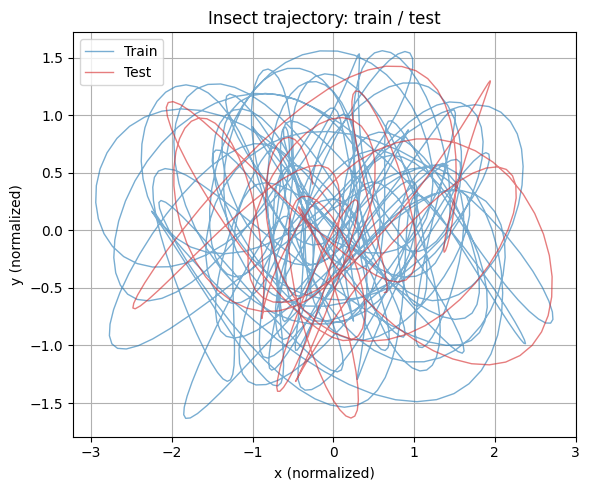

In [5]:
plt.figure(figsize=(6, 5))
plt.plot(x_train[:, 0], x_train[:, 1], c='tab:blue', lw=1, alpha=0.6, label='Train')
plt.plot(x_test[:, 0],  x_test[:, 1],  c='tab:red',  lw=1, alpha=0.6, label='Test')
plt.xlabel('x (normalized)'); plt.ylabel('y (normalized)')
plt.title('Insect trajectory: train / test')
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

## 4. Single-step windows

convert the continuous series into supervised `(input window → next point)`
samples that the models can train on.

Each sample is an input window of length `L` and the **single** next point as target:
`X[i] = data[i : i+L]`, `y[i] = data[i+L]`. Multi-step forecasting is obtained later
at inference time by feeding predictions back into the model (autoregressive rollout,
Section 8). The cell also wraps everything into PyTorch `DataLoader`s.

In [6]:
def make_windows(data, L):
    """Return X (N, L, C) and y (N, C): each window predicts the next point."""
    X, y = [], []
    for i in range(len(data) - L):
        X.append(data[i:i+L])
        y.append(data[i+L])
    return np.array(X, dtype='float32'), np.array(y, dtype='float32')


Xtr, ytr = make_windows(x_train, sequence_len)
Xte, yte = make_windows(x_test,  sequence_len)
print('X_train:', Xtr.shape, ' y_train:', ytr.shape)
print('X_test :', Xte.shape, ' y_test :', yte.shape)

train_loader = DataLoader(TensorDataset(torch.from_numpy(Xtr), torch.from_numpy(ytr)),
                          batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(TensorDataset(torch.from_numpy(Xte), torch.from_numpy(yte)),
                          batch_size=batch_size, shuffle=False)

X_train: (1568, 32, 2)  y_train: (1568, 2)
X_test : (368, 32, 2)  y_test : (368, 2)


## 5. Models

define the candidate forecasters behind one common interface so the rest
of the notebook is model-agnostic.

`Linear` is provided as a **worked example**. Implement the other models
(`MLP`, `RNN`, `LSTM`, `GRU`, `Transformer`) yourself, then uncomment them in the
`MODELS` factory. Every model maps an input window `(B, L, C)` to the next point
`(B, C)` — `B = batch, L = window length, C = channels = 2`.

In [7]:
class Linear(nn.Module):
    """Pure linear baseline (worked example): flatten the window -> next point."""
    def __init__(self, L, C):
        super().__init__()
        self.net = nn.Sequential(nn.Flatten(), nn.Linear(L * C, C))

    def forward(self, x):
        return self.net(x)


# ======================================================================
# TODO (PLACEHOLDER): implement the models below.
# L = window length (memory), C = number of channels (here x, y -> C=2).
# Same interface as Linear: input (B, L, C) -> output (B, C).
# Replace every  # >>> YOUR CODE HERE <<<  block, then delete the
# `raise NotImplementedError` line.
# ======================================================================

class MLP(nn.Module):
    def __init__(self, L, C, hidden=128):
        super().__init__()
        # >>> YOUR CODE HERE <<< : Flatten -> Linear -> ReLU -> ... -> Linear(C)
        raise NotImplementedError("TODO: build the MLP")

    def forward(self, x):
        # >>> YOUR CODE HERE <<<
        raise NotImplementedError


class RecurrentForecaster(nn.Module):
    """RNN / LSTM / GRU encoder + linear head on the last hidden output."""
    def __init__(self, cell, C, hidden=64):
        super().__init__()
        # >>> YOUR CODE HERE <<< : pick nn.RNN / nn.LSTM / nn.GRU from `cell`,
        #                          then add a Linear(hidden, C) head
        raise NotImplementedError("TODO: build the recurrent model")

    def forward(self, x):
        # >>> YOUR CODE HERE <<< : run the rnn, take the LAST time step, apply head
        raise NotImplementedError


class TransformerForecaster(nn.Module):
    def __init__(self, L, C, d_model=64, nhead=4, layers=2):
        super().__init__()
        # >>> YOUR CODE HERE <<< : input projection + positional encoding
        #                          + TransformerEncoder + Linear head
        raise NotImplementedError("TODO: build the Transformer")

    def forward(self, x):
        # >>> YOUR CODE HERE <<<
        raise NotImplementedError


# Factory: name -> builder(L, C).
# By default only the worked-example Linear model is active.
# TODO (PLACEHOLDER): uncomment each line below once that model is implemented.
MODELS = {
    'Linear':      lambda L, C: Linear(L, C),
    # 'MLP':         lambda L, C: MLP(L, C),                       # TODO
    # 'RNN':         lambda L, C: RecurrentForecaster('RNN', C),   # TODO
    # 'LSTM':        lambda L, C: RecurrentForecaster('LSTM', C),  # TODO
    # 'GRU':         lambda L, C: RecurrentForecaster('GRU', C),   # TODO
    # 'Transformer': lambda L, C: TransformerForecaster(L, C),     # TODO
}

## 6. Experiment: train & evaluate

provide reusable training / evaluation utilities used for every model.

The cell defines:
- `evaluate(model, loader)` — returns the single-step `(MSE, MAE)` on a data loader.
- `train_model(model, ...)` — trains with Adam + MSE loss and records the per-epoch
  train / validation loss history.

In [8]:
def evaluate(model, loader):
    """Return single-step (MSE, MAE) over a data loader."""
    model.eval()
    mse_sum, mae_sum, n = 0.0, 0.0, 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            pred = model(xb)
            mse_sum += nn.functional.mse_loss(pred, yb, reduction='sum').item()
            mae_sum += nn.functional.l1_loss(pred, yb, reduction='sum').item()
            n += yb.numel()
    return mse_sum / n, mae_sum / n


def train_model(model, train_loader, test_loader, epochs=epochs, lr=lr, verbose=False):
    model = model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    history = {'train': [], 'val': []}
    for ep in range(epochs):
        model.train()
        run = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            opt.step()
            run += loss.item() * len(xb)
        train_loss = run / len(train_loader.dataset)
        val_loss, _ = evaluate(model, test_loader)
        history['train'].append(train_loss)
        history['val'].append(val_loss)
        if verbose:
            print(f'  epoch {ep+1:2d}/{epochs}  train {train_loss:.4f}  val {val_loss:.4f}')
    return model, history

## 7. Compare the models

train every model in `MODELS`, then summarise their accuracy.

- The first cell trains each model and builds a **benchmark table** (pandas
  `DataFrame`) of single-step MSE / MAE, sorted best-first. By default only
  `Linear` runs; it grows automatically as you enable more models.
- The second cell **plots** the validation-loss curves and a bar chart of the
  test MSE for a quick visual comparison.

In [10]:
import pandas as pd

results = {}
for name, build in MODELS.items():
    print(f'Training {name} ...')
    torch.manual_seed(0)
    model, history = train_model(build(sequence_len, features_len),
                                 train_loader, test_loader)
    mse, mae = evaluate(model, test_loader)
    results[name] = {'model': model, 'history': history, 'mse': mse, 'mae': mae}

# ---- Benchmark table (single-step) ----
benchmark = pd.DataFrame(
    [{'Model': n, '1-step MSE': r['mse'], '1-step MAE': r['mae']} for n, r in results.items()]
).set_index('Model').sort_values('1-step MSE')
benchmark

Training Linear ...


,1-step MSE,1-step MAE
Model,,
Linear,0.008293,0.063147


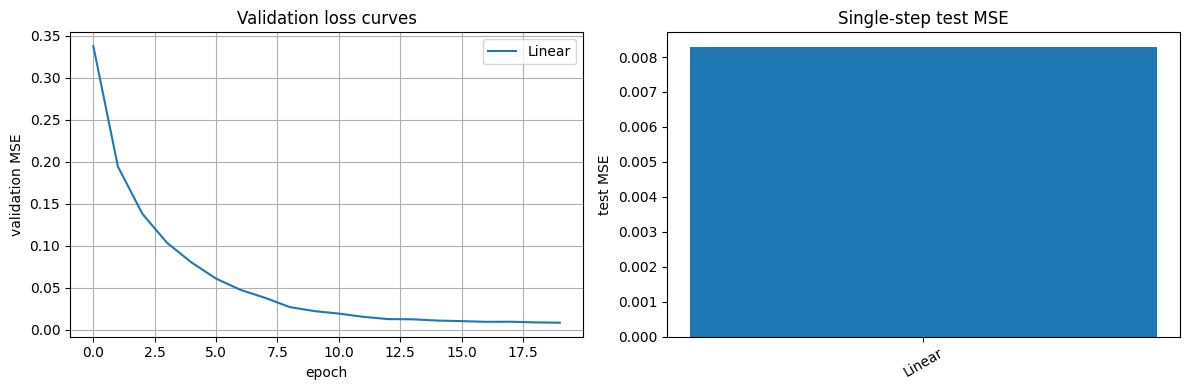

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

for name, r in results.items():
    ax1.plot(r['history']['val'], label=name)
ax1.set_xlabel('epoch'); ax1.set_ylabel('validation MSE')
ax1.set_title('Validation loss curves'); ax1.legend(); ax1.grid(True)

names = list(results.keys())
ax2.bar(names, [results[n]['mse'] for n in names], color='tab:blue')
ax2.set_ylabel('test MSE'); ax2.set_title('Single-step test MSE')
ax2.tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.show()

## 8. Autoregressive rollout (multi-step forecasting)

turn the single-step models into true `T`-step trajectory forecasters and
evaluate them on that harder task.

Starting from a real input window, the model predicts the next point; that prediction
is appended and the oldest point dropped, then we repeat for `T` steps.

The three cells below:
- define `rollout` (generate a forecast) and `rollout_rmse` (average error over the test set);
- add the **`T`-step rollout RMSE** column to the benchmark table and pick the best model;
- **plot** a few predicted vs. true trajectories for that best model.

In [12]:
def rollout(model, window, steps):
    """window: (L, C) numpy array -> predicted trajectory (steps, C)."""
    model.eval()
    seq = torch.from_numpy(window).float().unsqueeze(0).to(device)  # (1, L, C)
    preds = []
    with torch.no_grad():
        for _ in range(steps):
            nxt = model(seq)                       # (1, C)
            preds.append(nxt.squeeze(0).cpu().numpy())
            seq = torch.cat([seq[:, 1:, :], nxt.unsqueeze(1)], dim=1)
    return np.array(preds)


def rollout_rmse(model, data, L, steps):
    """Average RMSE of the rolled-out horizon over all valid start points."""
    errs = []
    for i in range(len(data) - L - steps):
        pred = rollout(model, data[i:i+L], steps)
        true = data[i+L:i+L+steps]
        errs.append(np.sqrt(((pred - true) ** 2).mean()))
    return float(np.mean(errs))

In [13]:
for name, r in results.items():
    r['rollout_rmse'] = rollout_rmse(r['model'], x_test, sequence_len, predict_len)

# ---- Add the multi-step rollout RMSE to the benchmark table ----
benchmark[f'{predict_len}-step rollout RMSE'] = [results[n]['rollout_rmse'] for n in benchmark.index]
benchmark = benchmark.sort_values(f'{predict_len}-step rollout RMSE')
best_name = benchmark.index[0]
print('Best model (rollout):', best_name)
benchmark

Best model (rollout): Linear


,1-step MSE,1-step MAE,32-step rollout RMSE
Model,,,
Linear,0.008293,0.063147,0.548872


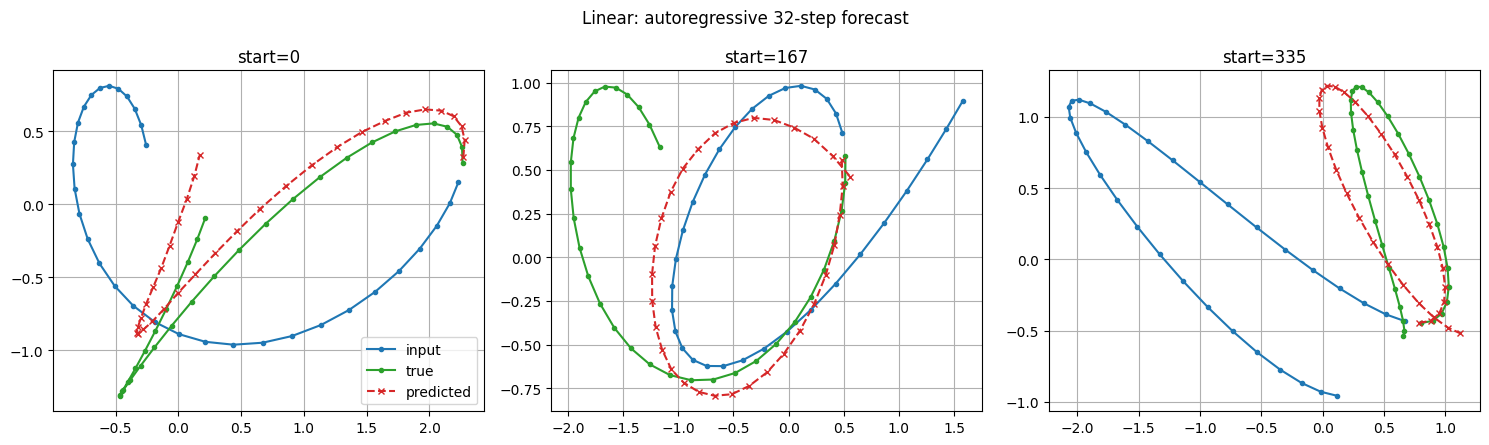

In [14]:
# Visualize a few rolled-out trajectories of the best model
best_model = results[best_name]['model']
starts = np.linspace(0, len(x_test) - sequence_len - predict_len - 1, 3, dtype=int)

fig, axes = plt.subplots(1, len(starts), figsize=(15, 4.5))
for ax, s in zip(axes, starts):
    window = x_test[s:s+sequence_len]
    pred   = rollout(best_model, window, predict_len)
    true   = x_test[s+sequence_len:s+sequence_len+predict_len]
    ax.plot(window[:, 0], window[:, 1], 'o-', c='tab:blue', ms=3, label='input')
    ax.plot(true[:, 0],  true[:, 1],  'o-', c='tab:green', ms=3, label='true')
    ax.plot(pred[:, 0],  pred[:, 1],  'x--', c='tab:red',  ms=4, label='predicted')
    ax.set_title(f'start={s}'); ax.grid(True)
axes[0].legend()
fig.suptitle(f'{best_name}: autoregressive {predict_len}-step forecast')
plt.tight_layout(); plt.show()

## 9. Conclusion

_Fill in from your own experiments._

**Models implemented:** Linear (given), ... _(list the ones you added)_

**Benchmark summary** (from the table in Section 7-8):
- Best single-step model (lowest 1-step MSE/MAE): ...
- Best multi-step model (lowest rollout RMSE): ...

**Observations** (one short line each):
- Linear baseline: ...
- MLP: ...
- RNN / LSTM / GRU: ...
- Transformer: ...

**Discussion:**
- Why does single-step error not directly predict rollout error? ...
- Why does the rollout error grow with the horizon `T`? ...
- Effect of standardisation on training: ...

**Conclusion:** ...